<a href="https://colab.research.google.com/github/VincentMunizAdrian/Trabajo-final---Data-Science---Review-Spotify/blob/main/Trabajo_final_Data_Science_Review_Spotify.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final - NLP y Deep Learning

## 📌 1. Introducción

### Analisis Review Spotify - Clasificación de Sentimiento en Reseñas de Spotify

#### Objetivo

Desarrollar un pipeline completo de Procesamiento de Lenguaje Natural (NLP) y Deep Learning para clasificar automáticamente reseñas de usuarios de Spotify en sentimientos positivos y negativos.

El proyecto incluye:

- Análisis Exploratorio de Datos (EDA)
- Preprocesamiento de texto
- Comparación entre NLTK y spaCy
- Representación numérica mediante TF-IDF
- Implementación de una red neuronal en PyTorch
- Evaluación e interpretación de resultados

##📂 2. Carga y Exploración Inicial del Dataset

En esta sección se carga el dataset de reseñas de Spotify y se realiza una inspección inicial de su estructura, dimensiones y variables.

### Importación de Librerías y carga de datos

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from collections import Counter
from wordcloud import WordCloud

import warnings
warnings.filterwarnings('ignore')

# Configuración gráfica
plt.style.use('ggplot')
sns.set_palette('Set2')

In [ ]:
# Carga de datos
df = pd.read_csv('/content/drive/MyDrive/Data Science III/Trabajo final/reviews.csv')

df.head()

,Time_submitted,Review,Rating,Total_thumbsup,Reply
0,2022-07-09 15:00:00,"Great music service, the audio is high quality...",5,2,NaN
1,2022-07-09 14:21:22,Please ignore previous negative rating. This a...,5,1,NaN
2,2022-07-09 13:27:32,"This pop-up ""Get the best Spotify experience o...",4,0,NaN
3,2022-07-09 13:26:45,Really buggy and terrible to use as of recently,1,1,NaN
4,2022-07-09 13:20:49,Dear Spotify why do I get songs that I didn't ...,1,1,NaN


## 📊 3. Análisis Exploratorio de Datos (EDA)

Se analiza la distribución de las variables principales para comprender la estructura del dataset y detectar posibles patrones relevantes para la clasificación.

### Análisis inicial

In [ ]:
# Dimensiones del dataset
print(f'Filas: {df.shape[0]}')
print(f'Columnas: {df.shape[1]}')

Filas: 61594
Columnas: 5


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61594 entries, 0 to 61593
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Time_submitted  61594 non-null  object
 1   Review          61594 non-null  object
 2   Rating          61594 non-null  int64 
 3   Total_thumbsup  61594 non-null  int64 
 4   Reply           216 non-null    object
dtypes: int64(2), object(3)
memory usage: 2.3+ MB


In [ ]:
# Valores faltantes
df.isnull().sum()

,0
Time_submitted,0
Review,0
Rating,0
Total_thumbsup,0
Reply,61378


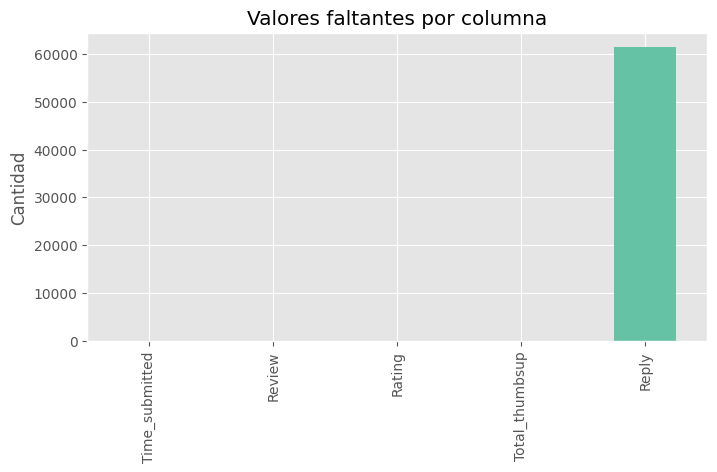

In [ ]:
missing = df.isnull().sum()

plt.figure(figsize=(8,4))
missing.plot(kind='bar')

plt.title('Valores faltantes por columna')
plt.ylabel('Cantidad')
plt.show()

In [ ]:
# Estadisticas descriptivas
df.describe()

,Rating,Total_thumbsup
count,61594.000000,61594.000000
mean,3.155989,7.649381
std,1.673285,89.323143
min,1.000000,0.000000
25%,1.000000,0.000000
50%,3.000000,0.000000
75%,5.000000,1.000000
max,5.000000,8195.000000


### Distribución de la variable Rating

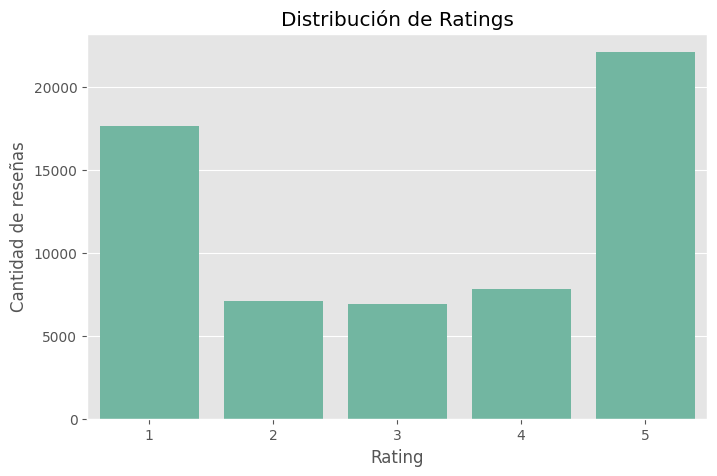

In [ ]:
# Grafico distribucion Rating
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Rating',
    order=sorted(df['Rating'].unique())
)

plt.title('Distribución de Ratings')
plt.xlabel('Rating')
plt.ylabel('Cantidad de reseñas')

plt.show()

In [ ]:
# Distribución porcentual
rating_pct = (
    df['Rating']
    .value_counts(normalize=True)
    .sort_index()*100
)

print(rating_pct.round(2))

Rating
1    28.66
2    11.56
3    11.18
4    12.73
5    35.87
Name: proportion, dtype: float64


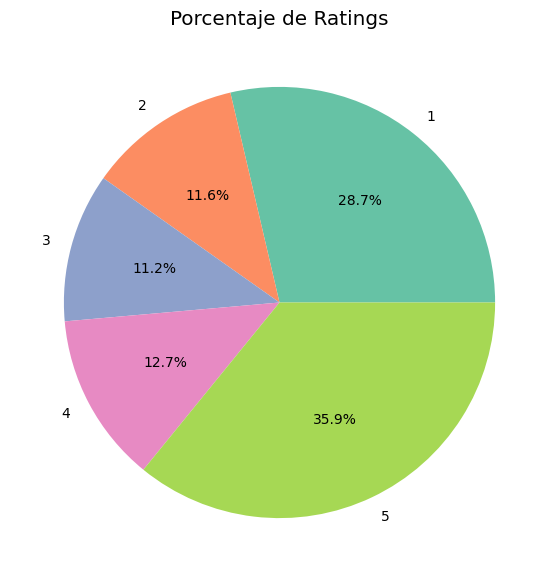

In [ ]:
# Gráfico circular
plt.figure(figsize=(7,7))

df['Rating'].value_counts().sort_index().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Porcentaje de Ratings')

plt.show()

### Creación de la variable Sentiment

A partir de la variable Rating se construye la variable Sentiment:

- Ratings 4 y 5 → Positive
- Ratings 1 y 2 → Negative
- Rating 3 → Neutral (eliminado del análisis)

In [ ]:
# Eliminamos neutros
df_sent = df[df['Rating'] != 3].copy()

In [ ]:
# Creamos variable Sentiment
df_sent['Sentiment'] = df_sent['Rating'].apply(
    lambda x: 'Positive' if x >= 4 else 'Negative'
)

In [ ]:
# Verificamos la nueva variable
df_sent[['Rating', 'Sentiment']].head()

,Rating,Sentiment
0,5,Positive
1,5,Positive
2,4,Positive
3,1,Negative
4,1,Negative


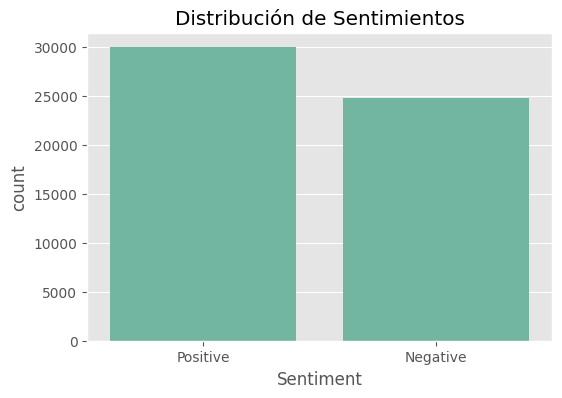

In [ ]:
# Distribución de la variable Sentiment
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_sent,
    x='Sentiment'
)

plt.title('Distribución de Sentimientos')

plt.show()

In [ ]:
# Porcentaje de clases
(
    df_sent['Sentiment']
    .value_counts(normalize=True)
    *100
).round(2)

,proportion
Sentiment,
Positive,54.72
Negative,45.28


### Longitud de reseñas

In [ ]:
# Cantidad de caracteres
df_sent['review_length'] = (
    df_sent['Review']
    .astype(str)
    .apply(len)
)

In [ ]:
# Estadísticas
df_sent['review_length'].describe()

,review_length
count,54708.000000
mean,159.480515
std,119.055963
min,10.000000
25%,70.000000
50%,125.000000
75%,215.000000
max,3753.000000


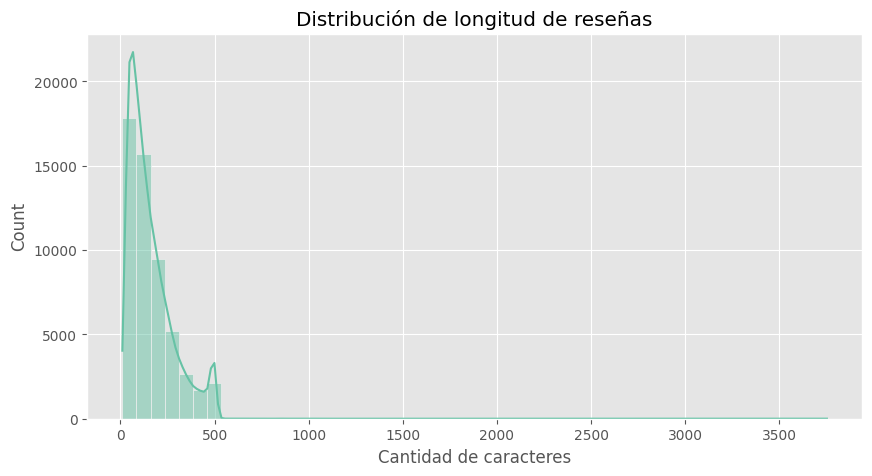

In [ ]:
# Histograma
plt.figure(figsize=(10,5))

sns.histplot(
    df_sent['review_length'],
    bins=50,
    kde=True
)

plt.title('Distribución de longitud de reseñas')
plt.xlabel('Cantidad de caracteres')

plt.show()

## 🧹 4. Preprocesamiento de Texto

El objetivo de esta etapa es limpiar y normalizar las reseñas para mejorar la calidad de la representación numérica utilizada por el modelo.


*   Conversión a Minúsculas
*   Limpieza mediante Expresiones Regulares (Regex)
*   Tokenización: Se realiza una comparación entre NLTK y spaCy para segmentar el texto en unidades léxicas (tokens).
*   Lematización: La lematización permite reducir palabras flexionadas a su forma base o lema.
*   Comparación NLTK vs spaCy
*   Eliminación de Stopwords







### Palabras más Frecuentes

In [ ]:
# Convertimos el texto de Review en minúsculas y creamos la variable Review_lower
df_sent['Review_lower'] = df_sent['Review'].apply(lambda text: text.lower())

In [ ]:
# Verificamos la nueva variable
df_sent[['Review', 'Review_lower']].head()

,Review,Review_lower
0,"Great music service, the audio is high quality...","great music service, the audio is high quality..."
1,Please ignore previous negative rating. This a...,please ignore previous negative rating. this a...
2,"This pop-up ""Get the best Spotify experience o...","this pop-up ""get the best spotify experience o..."
3,Really buggy and terrible to use as of recently,really buggy and terrible to use as of recently
4,Dear Spotify why do I get songs that I didn't ...,dear spotify why do i get songs that i didn't ...


In [ ]:
# Unir todos los textos
all_reviews = " ".join(
    df_sent['Review_lower'].astype(str)
)

In [ ]:
# Tokenización simple
words = all_reviews.lower().split()

In [ ]:
# Frecuencias
word_freq = Counter(words)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['Word','Frequency']
)

top_words

,Word,Frequency
0,the,61408
1,i,59494
2,to,56876
3,and,42015
4,it,34123
5,a,28191
6,is,25363
7,app,24348
8,my,20703
9,for,19686


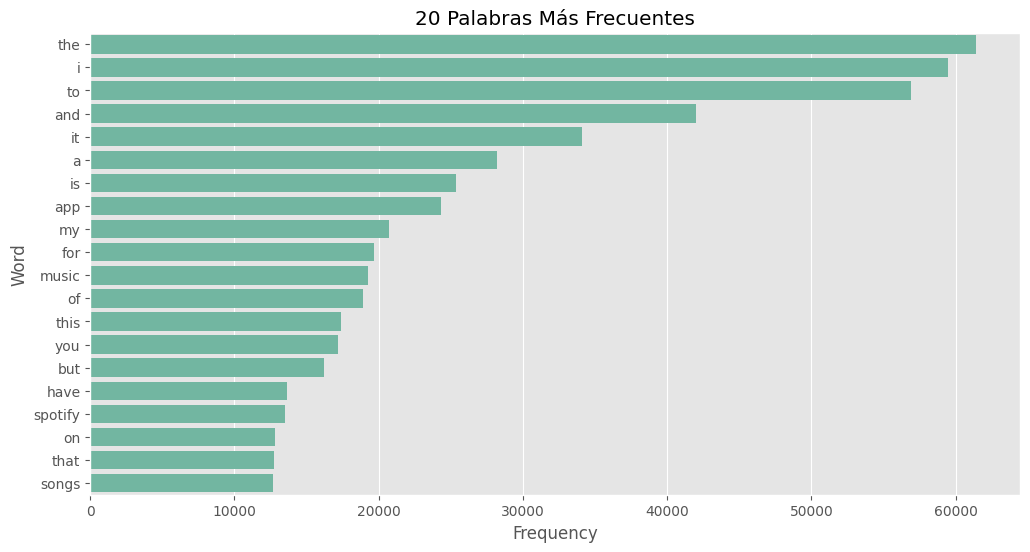

In [ ]:
# Grafico palabras más frecuentes
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_words,
    x='Frequency',
    y='Word'
)

plt.title('20 Palabras Más Frecuentes')

plt.show()

### WordCloud

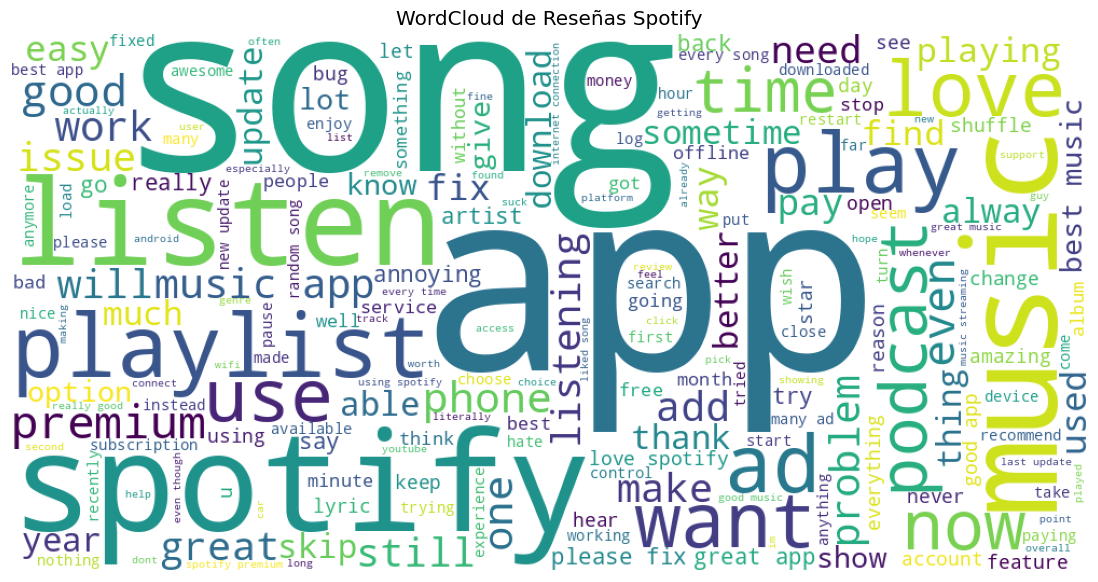

In [ ]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(all_reviews)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud)

plt.axis('off')

plt.title('WordCloud de Reseñas Spotify')

plt.show()

### Limpieza con Regex

In [ ]:
# Creamos una función que elimine números y espacios repetidos
def clean_text(text):

    # Eliminar URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Eliminar menciones tipo @usuario
    text = re.sub(r'@\w+', '', text)

    # Eliminar números
    text = re.sub(r'\d+', '', text)

    # Eliminar caracteres especiales
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Eliminar espacios múltiples
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

In [ ]:
# Aplicamos la función
df_sent['Review_clean'] = df_sent['Review_lower'].apply(clean_text)

In [ ]:
# Verificamos resultados
df_sent[
    ['Review',
     'Review_lower',
     'Review_clean']
].head(10)

,Review,Review_lower,Review_clean
0,"Great music service, the audio is high quality...","great music service, the audio is high quality...",great music service the audio is high quality ...
1,Please ignore previous negative rating. This a...,please ignore previous negative rating. this a...,please ignore previous negative rating this ap...
2,"This pop-up ""Get the best Spotify experience o...","this pop-up ""get the best spotify experience o...",this popup get the best spotify experience on ...
3,Really buggy and terrible to use as of recently,really buggy and terrible to use as of recently,really buggy and terrible to use as of recently
4,Dear Spotify why do I get songs that I didn't ...,dear spotify why do i get songs that i didn't ...,dear spotify why do i get songs that i didnt p...
6,I love the selection and the lyrics are provid...,i love the selection and the lyrics are provid...,i love the selection and the lyrics are provid...
8,It's a great app and the best mp3 music app I ...,it's a great app and the best mp3 music app i ...,its a great app and the best mp music app i ha...
9,"I'm deleting this app, for the following reaso...","i'm deleting this app, for the following reaso...",im deleting this app for the following reasons...
10,"Love Spotify, and usually this app is the best...","love spotify, and usually this app is the best...",love spotify and usually this app is the best ...
11,Can't play Spotify when on WiFi,can't play spotify when on wifi,cant play spotify when on wifi


### Tokenización con NLTK

In [ ]:
# Instalamos los recursos
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
# Creamos una función
from nltk.tokenize import word_tokenize

def tokenize_nltk(text):
    return word_tokenize(text)

In [ ]:
# Aplicamos la función
df_sent['tokens_nltk'] = (
    df_sent['Review_clean']
    .apply(tokenize_nltk)
)

### Tokeización con spaCy

In [ ]:
# Instalamos los recursos
!pip install spacy

!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Cargamos el modelo
import spacy

nlp = spacy.load("en_core_web_sm")

In [ ]:
# Creamos la función
def tokenize_spacy(text):

    doc = nlp(text)

    return [token.text for token in doc]

In [ ]:
# Aplicamos la función
df_sent['tokens_spacy'] = (
    df_sent['Review_clean']
    .apply(tokenize_spacy)
)

### Comparación de Tokenización NLTK vs spaCy

In [ ]:
# Controlamos algunos ejemplos
df_sent[
    ['Review',
     'tokens_nltk',
     'tokens_spacy']
].head(5)

,Review,tokens_nltk,tokens_spacy
0,"Great music service, the audio is high quality...","[great, music, service, the, audio, is, high, ...","[great, music, service, the, audio, is, high, ..."
1,Please ignore previous negative rating. This a...,"[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, t..."
2,"This pop-up ""Get the best Spotify experience o...","[this, popup, get, the, best, spotify, experie...","[this, popup, get, the, best, spotify, experie..."
3,Really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, as, of...","[really, buggy, and, terrible, to, use, as, of..."
4,Dear Spotify why do I get songs that I didn't ...,"[dear, spotify, why, do, i, get, songs, that, ...","[dear, spotify, why, do, i, get, songs, that, ..."


#### Conclusiones de la comparación

La tokenización produjo resultados prácticamente equivalentes en ambas bibliotecas. Sin embargo, spaCy mostró una lematización más precisa para verbos conjugados y contracciones, generando representaciones textuales más normalizadas que las obtenidas con WordNetLemmatizer de NLTK.

### Lematización con NLTK

In [ ]:
# Descargamos los recursos
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
# Importamos
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

In [ ]:
# Creamos la función
def lemmatize_nltk(tokens):

    return [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

In [ ]:
# Aplicamos
df_sent['lemmas_nltk'] = (
    df_sent['tokens_nltk']
    .apply(lemmatize_nltk)
)

### Lematización con spaCy

In [ ]:
# Función
def lemmatize_spacy(text):

    doc = nlp(text)

    return [
        token.lemma_
        for token in doc
    ]

In [ ]:
# Aplicación
df_sent['lemmas_spacy'] = (
    df_sent['Review_clean']
    .apply(lemmatize_spacy)
)

### Comparación Lematización NLTK vs spaCy

In [ ]:
sample = df_sent[
    ['Review_clean',
     'lemmas_nltk',
     'lemmas_spacy']
]

sample.head(10)

,Review_clean,lemmas_nltk,lemmas_spacy
0,great music service the audio is high quality ...,"[great, music, service, the, audio, is, high, ...","[great, music, service, the, audio, be, high, ..."
1,please ignore previous negative rating this ap...,"[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, t..."
2,this popup get the best spotify experience on ...,"[this, popup, get, the, best, spotify, experie...","[this, popup, get, the, good, spotify, experie..."
3,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, a, of,...","[really, buggy, and, terrible, to, use, as, of..."
4,dear spotify why do i get songs that i didnt p...,"[dear, spotify, why, do, i, get, song, that, i...","[dear, spotify, why, do, I, get, song, that, I..."
6,i love the selection and the lyrics are provid...,"[i, love, the, selection, and, the, lyric, are...","[I, love, the, selection, and, the, lyric, be,..."
8,its a great app and the best mp music app i ha...,"[it, a, great, app, and, the, best, mp, music,...","[its, a, great, app, and, the, good, mp, music..."
9,im deleting this app for the following reasons...,"[im, deleting, this, app, for, the, following,...","[I, m, delete, this, app, for, the, follow, re..."
10,love spotify and usually this app is the best ...,"[love, spotify, and, usually, this, app, is, t...","[love, spotify, and, usually, this, app, be, t..."
11,cant play spotify when on wifi,"[cant, play, spotify, when, on, wifi]","[can, not, play, spotify, when, on, wifi]"


In [ ]:
different = df_sent[
    df_sent['lemmas_nltk'].astype(str) !=
    df_sent['lemmas_spacy'].astype(str)
]

different[
    ['Review_clean',
     'lemmas_nltk',
     'lemmas_spacy']
].head(20)

,Review_clean,lemmas_nltk,lemmas_spacy
0,great music service the audio is high quality ...,"[great, music, service, the, audio, is, high, ...","[great, music, service, the, audio, be, high, ..."
1,please ignore previous negative rating this ap...,"[please, ignore, previous, negative, rating, t...","[please, ignore, previous, negative, rating, t..."
2,this popup get the best spotify experience on ...,"[this, popup, get, the, best, spotify, experie...","[this, popup, get, the, good, spotify, experie..."
3,really buggy and terrible to use as of recently,"[really, buggy, and, terrible, to, use, a, of,...","[really, buggy, and, terrible, to, use, as, of..."
4,dear spotify why do i get songs that i didnt p...,"[dear, spotify, why, do, i, get, song, that, i...","[dear, spotify, why, do, I, get, song, that, I..."
6,i love the selection and the lyrics are provid...,"[i, love, the, selection, and, the, lyric, are...","[I, love, the, selection, and, the, lyric, be,..."
8,its a great app and the best mp music app i ha...,"[it, a, great, app, and, the, best, mp, music,...","[its, a, great, app, and, the, good, mp, music..."
9,im deleting this app for the following reasons...,"[im, deleting, this, app, for, the, following,...","[I, m, delete, this, app, for, the, follow, re..."
10,love spotify and usually this app is the best ...,"[love, spotify, and, usually, this, app, is, t...","[love, spotify, and, usually, this, app, be, t..."
11,cant play spotify when on wifi,"[cant, play, spotify, when, on, wifi]","[can, not, play, spotify, when, on, wifi]"


### Eliminación de Stopwords

In [ ]:
# Importamos
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

In [ ]:
# Controlamos algunas
list(stop_words)[:20]

['ourselves',
 'out',
 "should've",
 'from',
 "it'd",
 'i',
 'they',
 'now',
 'him',
 'can',
 "mightn't",
 'my',
 'haven',
 'theirs',
 'you',
 "we'll",
 'so',
 'when',
 'yourselves',
 'there']

In [ ]:
# Aplicamos
df_sent['lemmas_spacy_clean'] = (
    df_sent['lemmas_spacy']
    .apply(
        lambda words: [
            word
            for word in words
            if word not in stop_words
            and len(word) > 2
        ]
    )
)

In [ ]:
# Convertimos la lista a texto
df_sent['text_final'] = (
    df_sent['lemmas_spacy_clean']
    .apply(lambda words: ' '.join(words))
)

In [ ]:
# Controlamos el resultado
df_sent[
    [
        'Review_clean',
        'text_final'
    ]
].head(10)

,Review_clean,text_final
0,great music service the audio is high quality ...,great music service audio high quality app eas...
1,please ignore previous negative rating this ap...,please ignore previous negative rating app sup...
2,this popup get the best spotify experience on ...,popup get good spotify experience android anno...
3,really buggy and terrible to use as of recently,really buggy terrible use recently
4,dear spotify why do i get songs that i didnt p...,dear spotify get song put playlist shuffle play
6,i love the selection and the lyrics are provid...,love selection lyric provide song listen
8,its a great app and the best mp music app i ha...,great app good music app ever use one problem ...
9,im deleting this app for the following reasons...,delete app follow reason app fail business mod...
10,love spotify and usually this app is the best ...,love spotify usually app good state control bu...
11,cant play spotify when on wifi,play spotify wifi


In [ ]:
# Verificamos palabras más frecuentes después de limpiar
from collections import Counter

all_words = []

for row in df_sent['lemmas_spacy_clean']:
    all_words.extend(row)

word_freq = Counter(all_words)

word_freq.most_common(20)

[('app', 33097),
 ('song', 27850),
 ('music', 23274),
 ('play', 17148),
 ('spotify', 16854),
 ('good', 11870),
 ('listen', 11529),
 ('use', 10392),
 ('like', 9083),
 ('love', 8975),
 ('playlist', 8593),
 ('get', 8364),
 ('premium', 7836),
 ('great', 6703),
 ('even', 6187),
 ('want', 6185),
 ('work', 5936),
 ('update', 5922),
 ('time', 5724),
 ('fix', 5112)]

## 🔢 5. Representación Numérica

#### Representación Numérica del Texto

Los algoritmos de aprendizaje automático requieren entradas numéricas. Para ello se utiliza la técnica TF-IDF.



### Vectorización con TF-IDF

In [ ]:
# Convertimos la lista de lemas a texto usando la lematización de spaCy
df_sent['text_final'] = df_sent['lemmas_spacy'].apply(
    lambda words: ' '.join(words)
)

In [ ]:
# Verificamos
df_sent[
    ['Review_clean',
     'text_final']
].head()

,Review_clean,text_final
0,great music service the audio is high quality ...,great music service the audio be high quality ...
1,please ignore previous negative rating this ap...,please ignore previous negative rating this ap...
2,this popup get the best spotify experience on ...,this popup get the good spotify experience on ...
3,really buggy and terrible to use as of recently,really buggy and terrible to use as of recently
4,dear spotify why do i get songs that i didnt p...,dear spotify why do I get song that I do not p...


### División Train/Test

In [ ]:
# Convertimos la variable objetivo a numérica
df_sent['Sentiment_num'] = (
    df_sent['Sentiment']
    .map({
        'Negative': 0,
        'Positive': 1
    })
)

In [ ]:
# Creamos variables X e y
X = df_sent['text_final']

y = df_sent['Sentiment_num']

In [ ]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### TF-IDF

In [ ]:
# Importamos
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Creamos el vectorizador
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

In [ ]:
# Ajustamos sobre Train
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [ ]:
# Verificamos dimensiones
print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(43766, 5000)
(10942, 5000)


TF-IDF fue seleccionado porque permite ponderar la importancia de cada término considerando tanto su frecuencia dentro de una reseña como su frecuencia en el corpus completo. De esta manera, palabras muy comunes reciben menor peso mientras que términos más representativos adquieren mayor relevancia para la clasificación de sentimientos.

### Analizar Vocabulario

In [ ]:
# Palabras más importantes aprendidas por TF-IDF
feature_names = tfidf.get_feature_names_out()

feature_names[:20]

array(['aa', 'aac', 'aap', 'ab', 'abandon', 'abd', 'ability', 'abit',
       'able', 'abomination', 'abroad', 'abruptly', 'absent', 'absolute',
       'absolutely', 'absolutley', 'absolutly', 'absurd', 'abt',
       'abundance'], dtype=object)

### Palabras más frecuentes según TF-IDF

In [ ]:
scores = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

top_words = pd.DataFrame({
    'word': feature_names,
    'score': scores
})

top_words = (
    top_words
    .sort_values(
        by='score',
        ascending=False
    )
)

top_words.head(20)

,word,score
237,app,0.067143
2833,music,0.061144
4015,song,0.060931
1869,good,0.045621
3203,play,0.042204
4098,spotify,0.041937
2559,listen,0.035432
2619,love,0.035253
56,ad,0.032128
4710,use,0.030043


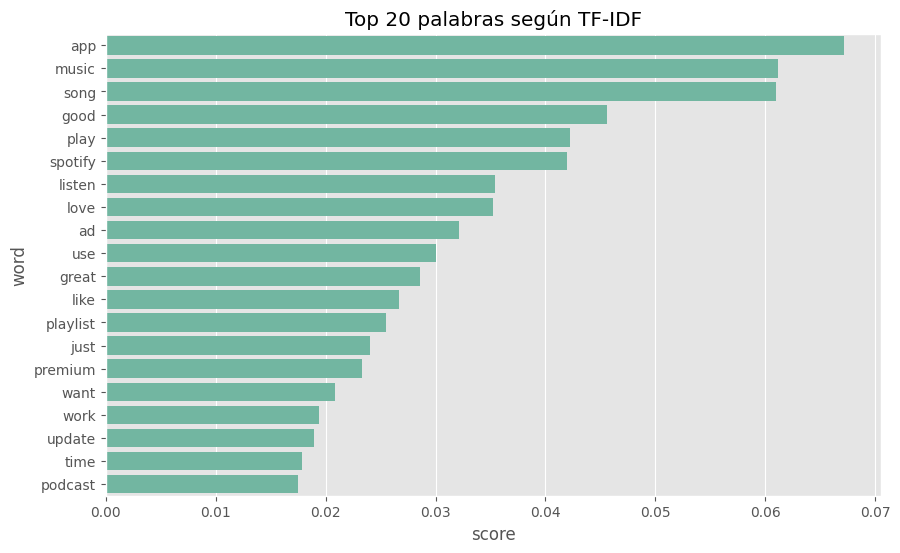

In [ ]:
# Visualización

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_words.head(20),
    x='score',
    y='word'
)

plt.title(
    'Top 20 palabras según TF-IDF'
)

plt.show()

### Preparación para PyTorch

In [ ]:
X_train_dense = X_train_tfidf.toarray()

X_test_dense = X_test_tfidf.toarray()

In [ ]:
# Convertimos a tensores
import torch

X_train_tensor = torch.FloatTensor(
    X_train_dense
)

X_test_tensor = torch.FloatTensor(
    X_test_dense
)

y_train_tensor = torch.LongTensor(
    y_train.values
)

y_test_tensor = torch.LongTensor(
    y_test.values
)

### Verificación

In [ ]:
# Balance de clases
y_train.value_counts(normalize=True) * 100

,proportion
Sentiment_num,
1,54.720559
0,45.279441


In [ ]:
# Forma de tensores
print(X_train_tensor.shape)
print(X_test_tensor.shape)

print(y_train_tensor.shape)
print(y_test_tensor.shape)

torch.Size([43766, 5000])
torch.Size([10942, 5000])
torch.Size([43766])
torch.Size([10942])


In [ ]:
# Numero de clases
df_sent['Sentiment_num'].unique()

array([1, 0])

## 🤖 6. Construcción del Modelo Deep Learning

#### Construcción del Modelo

Se implementa una red neuronal multicapa utilizando PyTorch para la clasificación binaria de sentimientos.

### Arquitectura de la Red

Arquitectura de la Red Neuronal

Se implementó una red neuronal multicapa utilizando PyTorch para realizar la clasificación binaria de sentimientos.

La arquitectura incluye:

- Capas densas (Fully Connected Layers).
- Funciones de activación ReLU.
- Batch Normalization para estabilizar el aprendizaje.
- Dropout con probabilidad de 0.5 para reducir el sobreajuste.
- Capa de salida con dos neuronas correspondientes a las clases Positive y Negative.

Esta configuración permite aprender patrones complejos presentes en las representaciones TF-IDF generadas previamente.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class TextClassifier(nn.Module):

    def __init__(self, input_size):

        super().__init__()

        self.fc1 = nn.Linear(input_size, 512)

        self.bn1 = nn.BatchNorm1d(512)

        self.dropout1 = nn.Dropout(0.5)

        self.fc2 = nn.Linear(512, 256)

        self.bn2 = nn.BatchNorm1d(256)

        self.dropout2 = nn.Dropout(0.5)

        self.fc3 = nn.Linear(256, 2)

    def forward(self, x):

        x = F.relu(self.fc1(x))

        x = self.bn1(x)

        x = self.dropout1(x)

        x = F.relu(self.fc2(x))

        x = self.bn2(x)

        x = self.dropout2(x)

        x = self.fc3(x)

        return x

In [ ]:
# Instanciamos el modelo
input_size = X_train_tensor.shape[1]

model = TextClassifier(input_size)

print(model)

TextClassifier(
  (fc1): Linear(in_features=5000, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc3): Linear(in_features=256, out_features=2, bias=True)
)


In [ ]:
# Función de pérdida - CrossEntropy
criterion = nn.CrossEntropyLoss()

In [ ]:
# Optimizador - Adam
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

### Creamos conjunto de validación - Early Stopping

In [ ]:
# Importamos
from sklearn.model_selection import train_test_split

In [ ]:
# Dividimos Train / Validation
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_tensor,
    y_train_tensor,
    test_size=0.20,
    random_state=42,
    stratify=y_train_tensor
)

In [ ]:
# Verificamos tamaños
print("Train:", X_train_final.shape)
print("Validation:", X_val.shape)
print("Test:", X_test_tensor.shape)

Train: torch.Size([35012, 5000])
Validation: torch.Size([8754, 5000])
Test: torch.Size([10942, 5000])


## ⚙️ 7. Entrenamiento del Modelo

Se configura el proceso de entrenamiento utilizando Adam, CrossEntropyLoss y Early Stopping.

### DataLoaders

In [ ]:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

In [ ]:
# Dataset de entrenamiento
train_dataset = TensorDataset(
    X_train_final,
    y_train_final
)

In [ ]:
# Dataset de validación
val_dataset = TensorDataset(
    X_val,
    y_val
)

In [ ]:
# Dataset de prueba
test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [ ]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

### Entrenamiento con Early Stopping

In [ ]:
# Variables de control
num_epochs = 50

patience = 5

best_val_loss = float('inf')

counter = 0

In [ ]:
# Listas para guardar métricas
train_losses = []

val_losses = []

In [ ]:
# Bucle de entrenamiento
for epoch in range(num_epochs):

    # ----------------
    # TRAIN
    # ----------------

    model.train()

    train_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ----------------
    # VALIDATION
    # ----------------

    model.eval()

    val_loss = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            val_loss += loss.item()

    val_loss /= len(val_loader)

    train_losses.append(train_loss)

    val_losses.append(val_loss)

    print(
        f'Epoch [{epoch+1}/{num_epochs}] '
        f'Train Loss: {train_loss:.4f} '
        f'Val Loss: {val_loss:.4f}'
    )

    # ----------------
    # EARLY STOPPING
    # ----------------

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        counter = 0

        torch.save(
            model.state_dict(),
            'best_model.pth'
        )

    else:

        counter += 1

        if counter >= patience:

            print(
                f'Early Stopping en época {epoch+1}'
            )

            break

Epoch [1/50] Train Loss: 0.3496 Val Loss: 0.3083
Epoch [2/50] Train Loss: 0.2678 Val Loss: 0.3228
Epoch [3/50] Train Loss: 0.2219 Val Loss: 0.3471
Epoch [4/50] Train Loss: 0.1724 Val Loss: 0.3828
Epoch [5/50] Train Loss: 0.1370 Val Loss: 0.4252
Epoch [6/50] Train Loss: 0.1152 Val Loss: 0.4630
Early Stopping en época 6


### Recuperar mejor modelo

In [ ]:
model.load_state_dict(
    torch.load('best_model.pth')
)

<All keys matched successfully>

## 📈 8. Resultados

### Graficar pérdidas

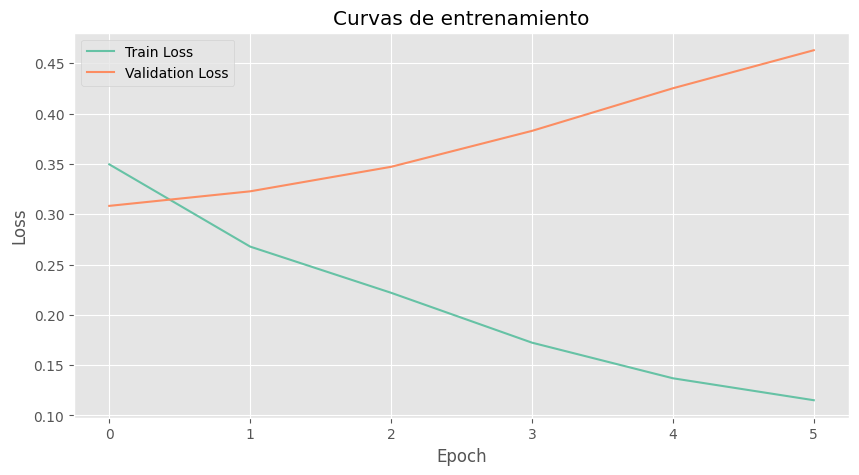

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    train_losses,
    label='Train Loss'
)

plt.plot(
    val_losses,
    label='Validation Loss'
)

plt.title(
    'Curvas de entrenamiento'
)

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.show()

#### Análisis del Entrenamiento

Durante el entrenamiento se observó una disminución sostenida de la pérdida sobre el conjunto de entrenamiento. Sin embargo, la pérdida de validación comenzó a incrementarse luego de las primeras épocas.

Este comportamiento indica la presencia de overfitting, es decir, que el modelo comienza a aprender patrones específicos del conjunto de entrenamiento que no generalizan correctamente sobre datos nuevos.

Para controlar este fenómeno se implementó Early Stopping con una paciencia de cinco épocas, conservando automáticamente el modelo con mejor desempeño de validación.

### Evaluación final

In [ ]:
# Metricas

# Accuracy
from sklearn.metrics import accuracy_score

# Classification Report
from sklearn.metrics import classification_report

# Confusion Matrix
from sklearn.metrics import confusion_matrix

In [ ]:
# Predicciones
model.eval()

predictions = []

true_labels = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch)

        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.numpy())

        true_labels.extend(y_batch.numpy())

In [ ]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(
    true_labels,
    predictions
)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.8799


In [ ]:
# Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predictions,
        target_names=[
            'Negative',
            'Positive'
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.85      0.89      0.87      4954
    Positive       0.91      0.87      0.89      5988

    accuracy                           0.88     10942
   macro avg       0.88      0.88      0.88     10942
weighted avg       0.88      0.88      0.88     10942



In [ ]:
# Matriz de Confusión
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    true_labels,
    predictions
)

cm

array([[4406,  548],
       [ 766, 5222]])

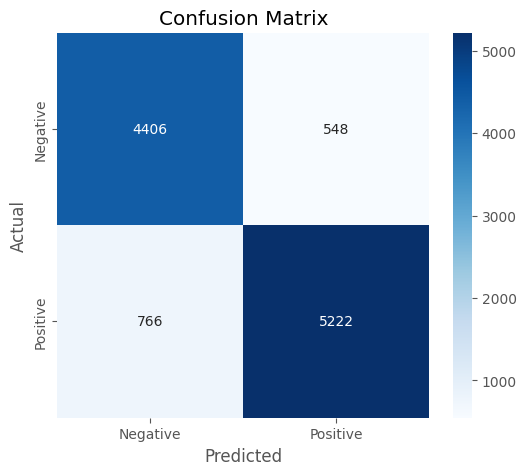

In [ ]:
# Visualización
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

#### Interpretación de Resultados

El modelo alcanzó una accuracy cercana al 88%, mostrando una capacidad adecuada para distinguir entre reseñas positivas y negativas.

La matriz de confusión evidencia que la mayoría de las observaciones fueron clasificadas correctamente. Los errores observados pueden estar relacionados con reseñas ambiguas o con opiniones mixtas que contienen simultáneamente elementos positivos y negativos.

Los resultados obtenidos permiten concluir que la combinación de preprocesamiento textual, TF-IDF y redes neuronales constituye una estrategia efectiva para esta tarea de clasificación.

## 📝 9. Conclusiones

Se desarrolló un pipeline completo de NLP y Deep Learning para la clasificación de sentimientos en reseñas de Spotify.

Los resultados obtenidos demostraron que la combinación de preprocesamiento textual, TF-IDF y redes neuronales permite alcanzar un desempeño satisfactorio, obteniendo una accuracy cercana al 88%.

Asimismo, se observó la presencia de overfitting durante el entrenamiento, mitigado mediante Early Stopping.

Como líneas futuras de trabajo podrían explorarse representaciones semánticas más avanzadas, como Word Embeddings o modelos basados en Transformers.